In [1]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

from RetinaFace import RetinaFace
from ArcFace import ArcFace
from identify import Gallery

In [2]:
retina = RetinaFace(ctx_id=-1)
arcface = ArcFace(ctx_id=-1)
gallery = Gallery()

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


/Users/tohid/Development/faceVision/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


found 300 snapshots
../volumes_backup/goldenset_images/f14e341b-cc9d-4284-81f0-5ffc87dfcd88.jpg
detected 1 face(s)
bbox=[1163.2523   190.80066 1213.427    249.08441] det_score=0.827 -> Tohid (score=0.583)


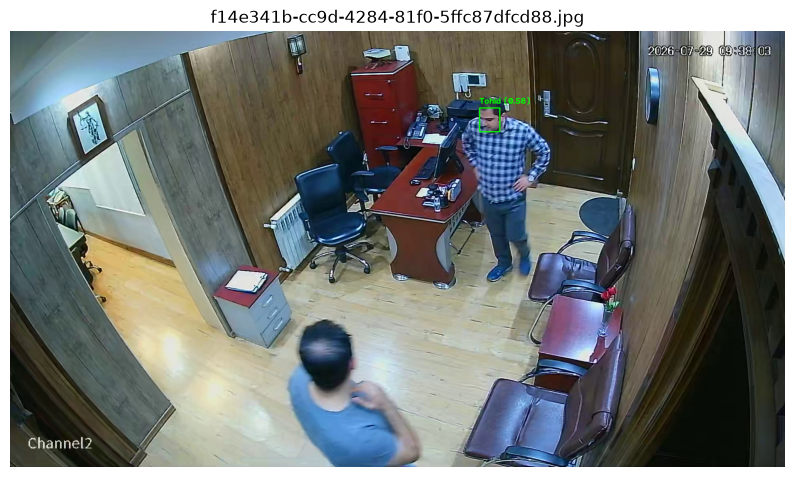

In [15]:
snapshots_dir = Path("../volumes_backup/goldenset_images")
image_paths = list(snapshots_dir.glob("*.jpg"))
print(f"found {len(image_paths)} snapshots")

image_path = random.choice(image_paths)
print(image_path)

image = cv2.imread(str(image_path))
assert image is not None, f"failed to read {image_path}"




faces = retina.detect(image)
print(f"detected {len(faces)} face(s)")

matches = []
for face in faces:
    aligned = retina.align(image, face.kps)
    embedding = arcface.embed(aligned)
    match = gallery.identify(embedding)
    matches.append(match)
    print(f"bbox={face.bbox} det_score={face.det_score:.3f} -> {match.label} (score={match.score:.3f})")
    
    
    

vis = image.copy()
for face, match in zip(faces, matches):
    x1, y1, x2, y2 = face.bbox.astype(int)
    color = (0, 255, 0) if match.label != "unknown" else (0, 0, 255)
    cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
    label = f"{match.label} ({match.score:.2f})"
    cv2.putText(
        vis,
        label,
        (x1, max(y1 - 10, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        color,
        2,
    )

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(image_path.name)
plt.show()